# Capstone Project - Modelling Feature Set B

This notebook covers building and evaluating models for Feature Set B, which includes all the original features plus my engineered features.

The main goals of this notebook are to:

1. Build and compare multiple classification models
2. Evaluate model performance using suitable metrics for an imbalanced classification problem
3. Compare models to see which perform best for my data

This notebook is kept separate from the EDA and feature engineering notebooks. The purpose here is to compare models for Feature Set B.


In [1]:
import sklearn
import imblearn
print("sklearn:", sklearn.__version__)
print("imblearn:", imblearn.__version__)

sklearn: 1.9.0
imblearn: 0.14.2


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from imblearn.ensemble import (
    BalancedRandomForestClassifier,
    BalancedBaggingClassifier,
    EasyEnsembleClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
repo = fetch_ucirepo(id=891)

X_raw = repo.data.features
y_raw = repo.data.targets

df = pd.concat([X_raw, y_raw], axis=1)

print("Dataset loaded successfully.")
print("Original shape:", df.shape)

Dataset loaded successfully.
Original shape: (253680, 22)


In [4]:
# Rename columns into easier format
df = df.rename(columns={
    'HighBP': 'high_bp',
    'HighChol': 'high_chol',
    'CholCheck': 'chol_check',
    'BMI': 'bmi',
    'Smoker': 'smoker',
    'Stroke': 'stroke',
    'HeartDiseaseorAttack': 'heart_disease',
    'PhysActivity': 'phys_activity',
    'Fruits': 'fruits',
    'Veggies': 'veggies',
    'HvyAlcoholConsump': 'heavy_alcohol',
    'AnyHealthcare': 'any_healthcare',
    'NoDocbcCost': 'no_doc_cost',
    'GenHlth': 'general_health',
    'MentHlth': 'mental_health_days',
    'PhysHlth': 'physical_health_days',
    'DiffWalk': 'difficulty_walking',
    'Sex': 'sex',
    'Age': 'age',
    'Education': 'education',
    'Income': 'income',
    'Diabetes_binary': 'diabetes'
})

df.head()

,high_bp,high_chol,chol_check,bmi,smoker,stroke,heart_disease,phys_activity,fruits,veggies,...,no_doc_cost,general_health,mental_health_days,physical_health_days,difficulty_walking,sex,age,education,income,diabetes
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [5]:
duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count / len(df)) * 100

print("Duplicate rows:", duplicate_count, "(" + str(round(duplicate_percent, 2)) + "% of the dataset)")

Duplicate rows: 24206 (9.54% of the dataset)


In [6]:
# Drop duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (229474, 22)


## 2.0 Defining Features and Target


In [7]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (229474, 21)
Target shape: (229474,)


In [8]:
target_summary = y.value_counts().to_frame(name='count')
target_summary['percentage'] = (y.value_counts(normalize=True) * 100).round(2)

target_summary

,count,percentage
diabetes,,
0,194377,84.71
1,35097,15.29


## 3.0 Feature Engineering

Feature Set B uses the same cleaned dataset as Feature Set A, but adds engineered features from my feature engineering notebook:

- `risk_factor_count`
- `overall_health_burden`
- BMI clinical categories (instead of raw `bmi`)

I repeat the engineering steps here so this notebook stays self-contained and reproducible.


In [9]:
# Create BMI categories using standard clinical cut-offs
bmi_bins = [0, 18.5, 25, 30, 35, 40, float('inf')]
bmi_labels = [
    'Underweight',
    'Normal weight',
    'Overweight',
    'Obese Class I',
    'Obese Class II',
    'Obese Class III'
]

df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=bmi_bins,
    labels=bmi_labels,
    right=False
)

df[['bmi', 'bmi_category']].head()

,bmi,bmi_category
0,40,Obese Class III
1,25,Overweight
2,28,Overweight
3,27,Overweight
4,24,Normal weight


In [10]:
risk_features = [
    'high_bp',
    'high_chol',
    'heart_disease',
    'difficulty_walking',
    'stroke'
]

df['risk_factor_count'] = df[risk_features].sum(axis=1)

df[['risk_factor_count']].describe()

,risk_factor_count
count,229474.000000
mean,1.229887
std,1.146698
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


In [11]:
df['overall_health_burden'] = (
    df['general_health'] +
    df['mental_health_days'] +
    df['physical_health_days']
)

df[['general_health', 'mental_health_days', 'physical_health_days', 'overall_health_burden']].head()

,general_health,mental_health_days,physical_health_days,overall_health_burden
0,5,18,15,38
1,3,0,0,3
2,5,30,30,65
3,2,0,0,2
4,2,3,0,5


In [12]:
df_model = pd.get_dummies(df, columns=['bmi_category'], drop_first=True)

df_model.head()

,high_bp,high_chol,chol_check,bmi,smoker,stroke,heart_disease,phys_activity,fruits,veggies,...,education,income,diabetes,risk_factor_count,overall_health_burden,bmi_category_Normal weight,bmi_category_Overweight,bmi_category_Obese Class I,bmi_category_Obese Class II,bmi_category_Obese Class III
0,1,1,1,40,1,0,0,0,0,1,...,4,3,0,3,38,False,False,False,False,True
1,0,0,0,25,1,0,0,1,0,0,...,6,1,0,0,3,False,True,False,False,False
2,1,1,1,28,0,0,0,0,1,0,...,4,8,0,3,65,False,True,False,False,False
3,1,0,1,27,0,0,0,1,1,1,...,3,6,0,1,2,False,True,False,False,False
4,1,1,1,24,0,0,0,1,1,1,...,5,4,0,2,5,True,False,False,False,False


For Feature Set B I removed raw `bmi` once the BMI category dummies were added, because both represent the same underlying information. I want to test whether the grouped clinical categories are more useful than the raw numeric BMI value.


## 4.0 Feature Selection B


In [13]:
# Feature Set B: original features plus engineered features
# Raw BMI removed because BMI is now represented through clinical BMI categories
feature_set_b = [
    'high_bp', 'high_chol', 'chol_check', 'smoker', 'stroke',
    'heart_disease', 'phys_activity', 'fruits', 'veggies',
    'heavy_alcohol', 'any_healthcare', 'no_doc_cost',
    'general_health', 'mental_health_days', 'physical_health_days',
    'difficulty_walking', 'sex', 'age', 'education', 'income',
    'risk_factor_count',
    'overall_health_burden',
    'bmi_category_Normal weight',
    'bmi_category_Overweight',
    'bmi_category_Obese Class I',
    'bmi_category_Obese Class II',
    'bmi_category_Obese Class III'
]

## 5.0 Defining Target Variable and Feature Set


In [14]:
y = df_model['diabetes']
X_b = df_model[feature_set_b]

print('Feature Set B shape:', X_b.shape)

Feature Set B shape: (229474, 27)


## Feature Set B


This notebook looks at Feature Set B, which contains the original features plus my engineered features (27 predictors in total).

For each model, I will look at:

- training accuracy
- test accuracy
- classification report
- confusion matrix
- false positives
- false negatives

At the end of the notebook I will add my conclusions for this feature set.


## 5.1 First Model: Logistic Regression


In [15]:
# Results list - create ONCE at the start of modelling, not inside each model
all_results = []

# Same split settings for every model in this notebook
TEST_SIZE = 0.25
RANDOM_STATE = 42

### Reproducibility settings

- Data: UCI BRFSS 2015 (id=891), duplicates removed → 229,474 rows
- Feature Set B: 27 predictors (original + engineered features)
- Split: 75/25 stratified, `random_state=42`
- Scaling: `StandardScaler` fit on train only
- Slow models: 20k train subsample (RBF SVM, Balanced Random Forest, Easy Ensemble)
- Ensembles: 30k train subsample (Voting, Stacking)
- Balanced Bagging: full training set
- Evaluation: full test set (57,369 rows)


In [16]:
X = X_b
y = df_model['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:")
y_train_balance = y_train.value_counts(normalize=True)
print(y_train_balance.round(4))
print("Test class balance:")
y_test_balance = y_test.value_counts(normalize=True)
print(y_test_balance.round(4))

Train shape: (172105, 27)  Test shape: (57369, 27)
Train class balance:
diabetes
0    0.8471
1    0.1529
Name: proportion, dtype: float64
Test class balance:
diabetes
0    0.8471
1    0.1529
Name: proportion, dtype: float64


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
log_model = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

model = log_model
model_name = "Logistic Regression"

In [19]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7175
Training Classification Report:
              precision    recall  f1-score   support

           0     0.9422    0.7100    0.8098    145782
           1     0.3209    0.7589    0.4510     26323

    accuracy                         0.7175    172105
   macro avg     0.6315    0.7344    0.6304    172105
weighted avg     0.8472    0.7175    0.7549    172105



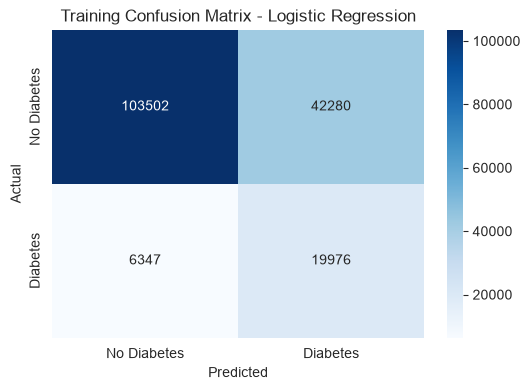

Training Confusion Matrix Breakdown
True Negatives:  103502
False Positives: 42280
False Negatives: 6347
True Positives:  19976


In [20]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [21]:
y_test_pred = model.predict(X_test_scaled)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7168
Precision:      0.3206
Recall:         0.7613
F1-score:       0.4512
ROC AUC:        0.8115

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9427    0.7087    0.8091     48595
           1     0.3206    0.7613    0.4512      8774

    accuracy                         0.7168     57369
   macro avg     0.6316    0.7350    0.6302     57369
weighted avg     0.8475    0.7168    0.7544     57369



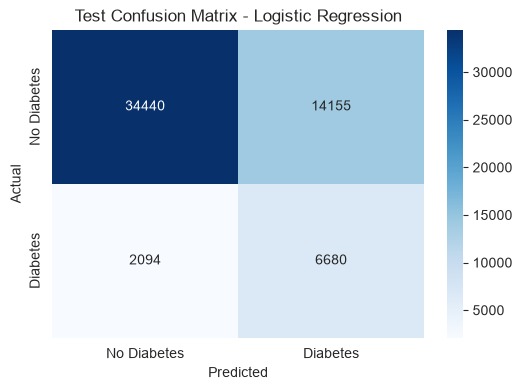

Test Confusion Matrix Breakdown
True Negatives:  34440
False Positives: 14155
False Negatives: 2094
True Positives:  6680


In [22]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [23]:
logistic_results_b = {
    'Feature Set': 'B',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(logistic_results_b)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,B,Logistic Regression,0.7175,0.7168,0.3206,0.7613,0.4512,0.8115,14155,2094


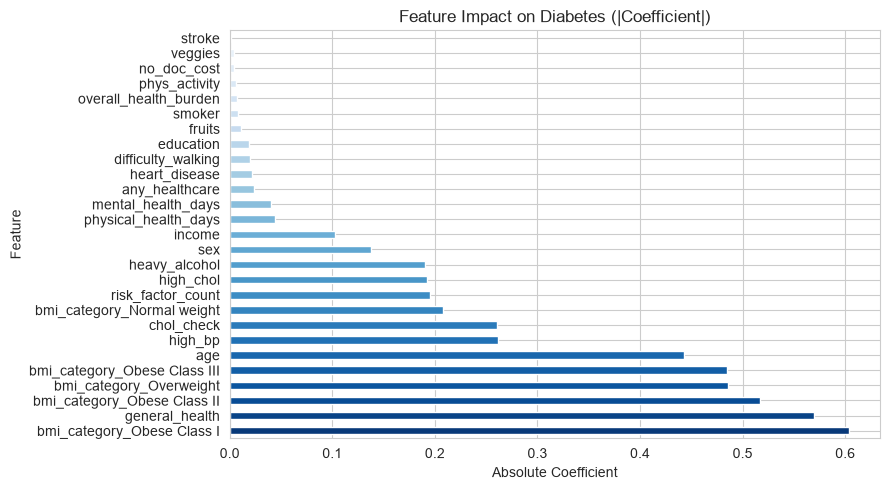

In [24]:
# Which features had the strongest effect (absolute coefficient size)
coef = pd.Series(
    np.abs(log_model.coef_[0]),
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
coef.plot(kind='barh', color=sns.color_palette('Blues_r', len(coef)))
plt.title('Feature Impact on Diabetes (|Coefficient|)')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Observation


Logistic regression gives me a strong starting point because it is simple and easy to interpret.

On Feature Set B, the training and test accuracy were very similar (0.7175 vs 0.7168), which shows the model is performing well and is not underfitting or overfitting. What I am particularly interested in for my dataset is the false negatives (saying someone does not have diabetes when they in fact do). On the test set, the model had 2,094 false negatives. This is very close to Feature Set A (2,106 false negatives), but Feature Set B missed slightly fewer cases. Recall was also very similar compared with Feature Set A, so the engineered features did not hurt performance and may have helped a little.

However, precision was only 0.32, which means that although accuracy was around 0.72, many of the people flagged as at risk were false alarms. Because of that, I still need to look at other models to see whether more advanced models can improve recall and precision further or capture non-linear patterns better.

The feature impact chart also shows a clear difference between Feature Set A and Feature Set B. On Feature Set A, `bmi` was one strong predictor (absolute coefficient around 0.47), but it was still a single numeric value. On Feature Set B, replacing raw BMI with clinical BMI categories gave a more detailed picture. `bmi_category_Obese Class I` had the strongest effect overall (around 0.61), followed by `general_health`, then `bmi_category_Obese Class II`, `bmi_category_Overweight`, and `bmi_category_Obese Class III`. This suggests that obesity level matters for diabetes risk in different ways, and grouping BMI into clinical classes helps the model separate risk more clearly than one continuous BMI value alone.

My engineered feature `risk_factor_count` also had a noticeable effect (around 0.20), while `overall_health_burden` had a smaller impact in this model. Overall, Feature Set B looks promising because the BMI category dummies, especially Obese Class I, show strong effects on diabetes prediction.


## 5.2 Second Model - Support Vector Machines - Linear Kernel

Linear SVM is my second model. Like logistic regression, it finds a linear decision boundary, but it uses a different approach (maximising the margin between classes).

I am using `LinearSVC` instead of `SVC(kernel='linear')` because it trains faster on large datasets like mine.

For ROC AUC, Linear SVM does not give probabilities, so I use `decision_function` scores instead.


In [25]:
# Train/test split and scaling already set up in Section 5.1
# Reusing X_train_scaled, X_test_scaled, y_train, y_test
print("Reusing existing split - Train:", X_train.shape, " Test:", X_test.shape)

Reusing existing split - Train: (172105, 27)  Test: (57369, 27)


In [26]:
# X_train_scaled and X_test_scaled already created in Section 5.1

In [27]:
from sklearn.svm import LinearSVC

In [28]:
linear_svm_model = LinearSVC(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=20000
)

linear_svm_model.fit(X_train_scaled, y_train)

model = linear_svm_model
model_name = "Linear SVM"

In [29]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7132

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9431    0.7038    0.8061    145782
           1     0.3180    0.7648    0.4492     26323

    accuracy                         0.7132    172105
   macro avg     0.6306    0.7343    0.6277    172105
weighted avg     0.8475    0.7132    0.7515    172105



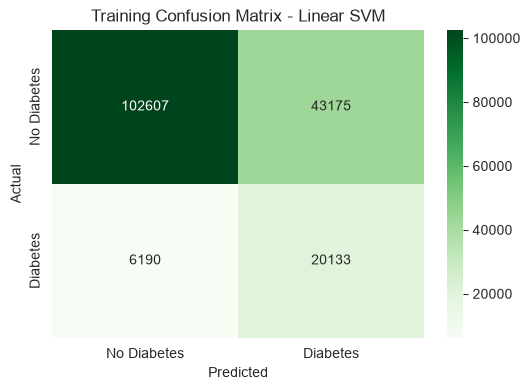

Training Confusion Matrix Breakdown
True Negatives:  102607
False Positives: 43175
False Negatives: 6190
True Positives:  20133


In [30]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [31]:
y_test_pred = model.predict(X_test_scaled)

y_test_scores = model.decision_function(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_scores)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7125
Precision:      0.3180
Recall:         0.7683
F1-score:       0.4498
ROC AUC:        0.8114

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9438    0.7025    0.8054     48595
           1     0.3180    0.7683    0.4498      8774

    accuracy                         0.7125     57369
   macro avg     0.6309    0.7354    0.6276     57369
weighted avg     0.8481    0.7125    0.7510     57369



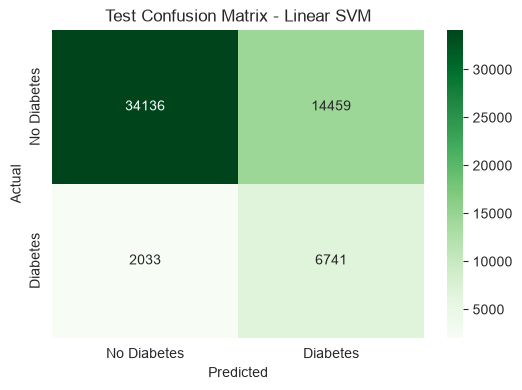

Test Confusion Matrix Breakdown
True Negatives:  34136
False Positives: 14459
False Negatives: 2033
True Positives:  6741


In [32]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [33]:
linear_svm_results_b = {
    'Feature Set': 'B',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(linear_svm_results_b)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,B,Logistic Regression,0.7175,0.7168,0.3206,0.7613,0.4512,0.8115,14155,2094
1,B,Linear SVM,0.7132,0.7125,0.3180,0.7683,0.4498,0.8114,14459,2033


### Observation


On Feature Set B, Linear SVM achieved a test recall of 0.7683 with 2,033 false negatives on the full test set (57,369 rows).

Compared with logistic regression on Feature Set B (recall 0.7613, 2,094 false negatives), Linear SVM caught slightly more diabetes cases, with 61 fewer false negatives. That matters for this project because missing someone at risk is worse than a false alarm.

Both models had very similar overall performance:

- Test accuracy: logistic regression 0.7168 vs Linear SVM 0.7125
- ROC AUC: both around 0.81
- Precision: both around 0.32 (many false positives)

Linear SVM had slightly more false positives (14,459 vs 14,155), which is the trade-off from using `class_weight='balanced'` to push recall higher.

Overall, Linear SVM is slightly stronger on recall and false negatives, which is my main priority for diabetes screening. I will keep both models in the comparison and move on to RBF SVM next to see if a non-linear model can improve further.


## 5.3 Third Model - RBF SVM

RBF SVM can capture non-linear patterns that logistic regression and Linear SVM cannot.

Because RBF SVM is very slow on large datasets, I train on a stratified subsample of 20,000 rows and evaluate on the full test set (57,369 rows).

Important:

- I did not use `probability=True` because it can take a long time on large data.
- I use `decision_function` for ROC AUC instead of `predict_proba`.

In [34]:
X_train_sub, X_train_sub_rest, y_train_sub, y_train_sub_rest = train_test_split(
    X_train_scaled,
    y_train,
    train_size=20000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

print("Train subsample shape:", X_train_sub.shape)
print("Train subsample class balance:")
y_train_sub_balance = y_train_sub.value_counts(normalize=True)
print(y_train_sub_balance.round(4))

Train subsample shape: (20000, 27)

Train subsample class balance:
diabetes
0    0.847
1    0.153
Name: proportion, dtype: float64


In [35]:
rbf_svm_model = SVC(
    kernel='rbf',
    C=0.3,
    gamma='scale',
    class_weight='balanced',
    random_state=RANDOM_STATE
)

rbf_svm_model.fit(X_train_sub, y_train_sub)

model = rbf_svm_model
model_name = "RBF SVM"

In [36]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.7305

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9559    0.7148    0.8180     16941
           1     0.3411    0.8176    0.4813      3059

    accuracy                         0.7305     20000
   macro avg     0.6485    0.7662    0.6496     20000
weighted avg     0.8619    0.7305    0.7665     20000



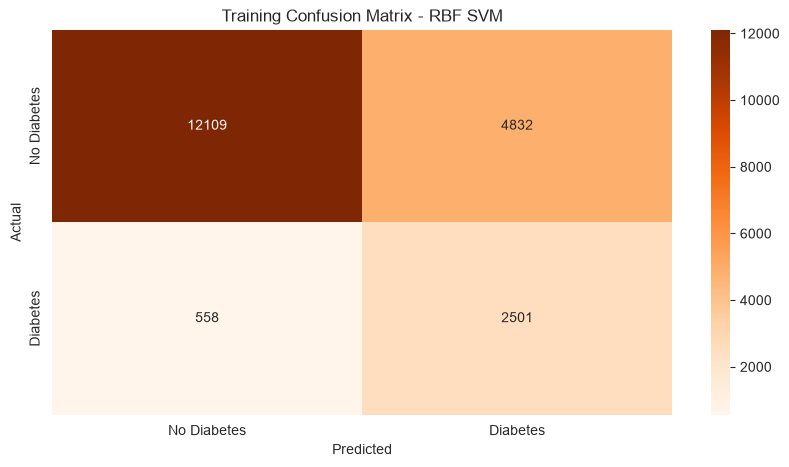

Training Confusion Matrix Breakdown
True Negatives: 12109
False Positives: 4832
False Negatives: 558
True Positives: 2501


In [37]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [38]:
y_test_pred = model.predict(X_test_scaled)
y_test_scores = model.decision_function(X_test_scaled)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_scores)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7074
Precision:      0.3136
Recall:         0.7678
F1-score:       0.4453
ROC AUC:        0.7998

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9432    0.6965    0.8013     48595
           1     0.3136    0.7678    0.4453      8774

    accuracy                         0.7074     57369
   macro avg     0.6284    0.7322    0.6233     57369
weighted avg     0.8469    0.7074    0.7468     57369



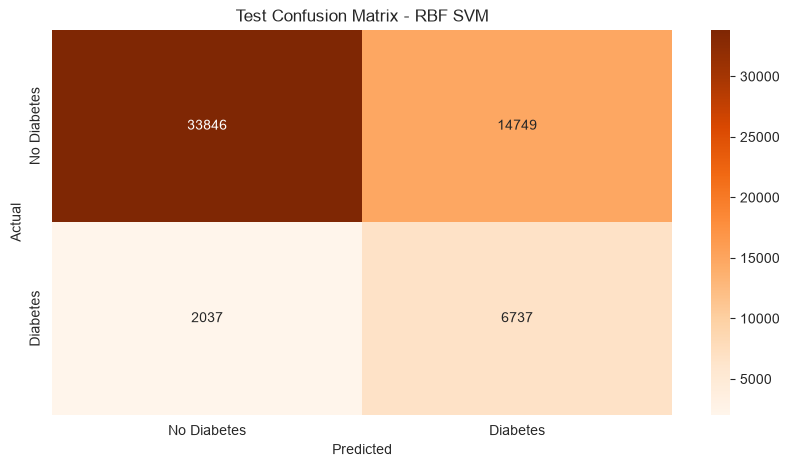

Test Confusion Matrix Breakdown
True Negatives: 33846
False Positives: 14749
False Negatives: 2037
True Positives: 6737


In [39]:
test_cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [40]:
rbf_svm_results_b = {
    'Feature Set': 'B',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(rbf_svm_results_b)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,B,Logistic Regression,0.7175,0.7168,0.3206,0.7613,0.4512,0.8115,14155,2094
1,B,Linear SVM,0.7132,0.7125,0.3180,0.7683,0.4498,0.8114,14459,2033
2,B,RBF SVM,0.7305,0.7074,0.3136,0.7678,0.4453,0.7998,14749,2037


### Observation

RBF SVM was included to test whether a non-linear model could capture more complex relationships than logistic regression and Linear SVM.

Because of the size of the dataset, I trained RBF SVM on a stratified subsample of 20,000 rows and evaluated it on the full test set.

RBF SVM achieved a test recall of 0.7678 and an F1-score of 0.4453, with 2,037 false negatives. That is close to Linear SVM (0.7683 recall, 2,033 FN) and slightly behind Balanced Bagging later in this notebook. Precision was lower at 0.31, meaning the model also produced more false positives. This is a trade-off I noticed across several models: higher recall often comes with lower precision.

Overall, RBF SVM performed similarly to the linear models on Feature Set B. Non-linear patterns may still be present, but the engineered features did not give RBF SVM a clear advantage here.


## 5.4 Fourth Model - Gaussian Naive Bayes

Gaussian Naive Bayes is a fast probabilistic benchmark. It assumes features are independent, which is not fully true for health data (BMI, blood pressure, and similar factors are related), but it is still useful for comparison.

Because it is very fast, I train on the full train set (not a subsample).


In [41]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
model = nb_model
model_name = "Gaussian Naive Bayes"

In [42]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7536

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9156    0.7811    0.8430    145782
           1     0.3315    0.6010    0.4273     26323

    accuracy                         0.7536    172105
   macro avg     0.6235    0.6911    0.6352    172105
weighted avg     0.8262    0.7536    0.7794    172105



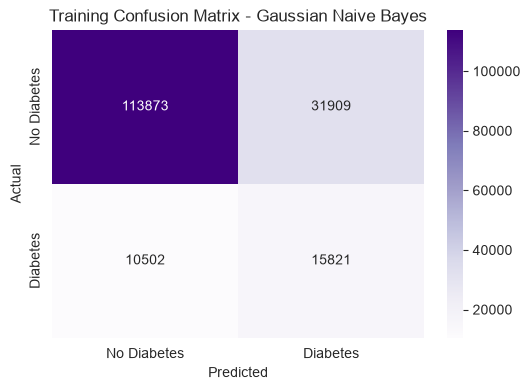

Training Confusion Matrix Breakdown
True Negatives:  113873
False Positives: 31909
False Negatives: 10502
True Positives:  15821


In [43]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [44]:
y_test_pred = model.predict(X_test_scaled)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy:  0.7530
Precision:      0.3313
Recall:         0.6041
F1-score:       0.4279
ROC AUC:        0.7767

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9160    0.7799    0.8425     48595
           1     0.3313    0.6041    0.4279      8774

    accuracy                         0.7530     57369
   macro avg     0.6237    0.6920    0.6352     57369
weighted avg     0.8266    0.7530    0.7791     57369



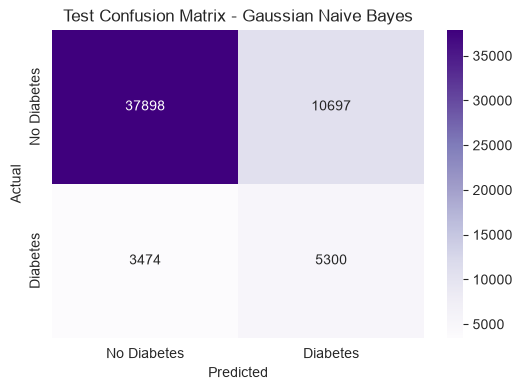

Test Confusion Matrix Breakdown
True Negatives:  37898
False Positives: 10697
False Negatives: 3474
True Positives:  5300


In [45]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)
plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [46]:
nb_results_b = {
    'Feature Set': 'B',
    'Model': 'Gaussian Naive Bayes',
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(nb_results_b)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,B,Logistic Regression,0.7175,0.7168,0.3206,0.7613,0.4512,0.8115,14155,2094
1,B,Linear SVM,0.7132,0.7125,0.3180,0.7683,0.4498,0.8114,14459,2033
2,B,RBF SVM,0.7305,0.7074,0.3136,0.7678,0.4453,0.7998,14749,2037
3,B,Gaussian Naive Bayes,0.7536,0.7530,0.3313,0.6041,0.4279,0.7767,10697,3474


### Observation


Gaussian Naive Bayes was the fastest model to train and run, which made it a useful benchmark. It achieved the highest test accuracy so far on Feature Set B at 0.753. However, its recall was lower at 0.6041, and it produced 3,474 false negatives. 

This means it missed more diabetes cases than logistic regression, Linear SVM, and RBF SVM. In this project, recall is more important than accuracy because a false negative means a potentially at-risk person would not be identified. For that reason, Naive Bayes is not the preferred model despite its speed and relatively strong accuracy. 

One possible reason is that Naive Bayes assumes the input features are conditionally independent, which is unlikely to be correct for health-related variables such as BMI, blood pressure, and general health, since these factors are often correlated.

## 6.0 Ensemble Methods


### Ensemble Models Overview

Ensemble methods combine multiple models to improve predictive performance.

This project uses five ensemble approaches:

1. Balanced Random Forest - builds decision trees on balanced bootstrap samples to improve minority-class detection.
2. Balanced Bagging - trains base learners on balanced subsets and averages their predictions to reduce variance and bias.
3. Easy Ensemble - creates several balanced subsets and applies boosting to each, enhancing recall for imbalanced datasets.
4. Voting Classifier - combines predictions from multiple models using soft voting to produce a more stable final probability.
5. Stacking Classifier - trains a meta-model on the outputs of base models to learn the best way to combine predictions

### 6.1 Balanced Random Forest

Balanced Random Forest is a variant of the Random Forest algorithm designed for imbalanced datasets.

It builds multiple decision trees using balanced bootstrap samples. Each tree is trained on a subset where the minority and majority classes are equally represented.

This helps prevent bias toward the majority class (non-diabetes) and improves recall for the minority class (diabetes).


In [47]:
brf_model = BalancedRandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

brf_model.fit(X_train_sub, y_train_sub)

model = brf_model
model_name = "Balanced Random Forest"

In [48]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.8861

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.8657    0.9280     16941
           1     0.5733    0.9997    0.7287      3059

    accuracy                         0.8861     20000
   macro avg     0.7866    0.9327    0.8283     20000
weighted avg     0.9347    0.8861    0.8975     20000



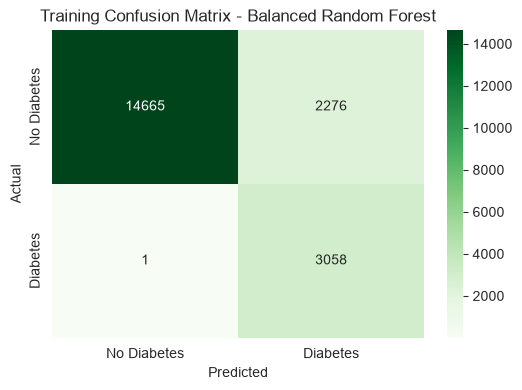

Training Confusion Matrix Breakdown
True Negatives:  14665
False Positives: 2276
False Negatives: 1
True Positives:  3058


In [49]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [50]:
y_test_pred = model.predict(X_test)
y_test_proba_all = model.predict_proba(X_test)
y_test_proba = y_test_proba_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("Test Accuracy", round(test_acc, 4))
print("Test Precision", round(test_precision, 4))
print("Test Recall", round(test_recall, 4))
print("Test F1 Score", round(test_f1, 4))
print("Test ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.5570
Test Precision: 0.2286
Test Recall: 0.7990
Test F1 Score: 0.3555
Test ROC AUC: 0.6947

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9340    0.5133    0.6625     48595
           1     0.2286    0.7990    0.3555      8774

    accuracy                         0.5570     57369
   macro avg     0.5813    0.6561    0.5090     57369
weighted avg     0.8261    0.5570    0.6156     57369



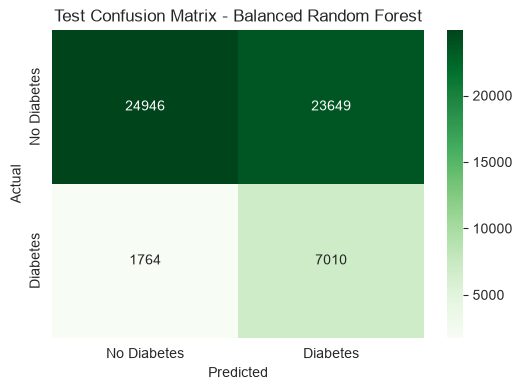

Test Confusion Matrix Breakdown
True Negatives:  24946
False Positives: 23649
False Negatives: 1764
True Positives:  7010


In [51]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation


Balanced Random Forest achieved extremely high recall on the training data, but its performance dropped substantially on the test set, suggesting overfitting and weak generalisation. Training accuracy was 0.89, while test accuracy fell to 0.56. Although the model still achieved high recall on the test set (0.80), this came at the cost of very low precision (0.23) and a very high number of false positives (23,649). This means the model identified many diabetes cases, but it also incorrectly labelled a large number of non-diabetic cases as diabetic. In the context of this project, high recall is important because missing a diabetes case is costly, but the number of false positives here is too high to make the model practical for deployment.

In [52]:
brf_results_b = {
    'Feature Set': 'B',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(brf_results_b)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,B,Logistic Regression,0.7175,0.7168,0.3206,0.7613,0.4512,0.8115,14155,2094
1,B,Linear SVM,0.7132,0.7125,0.3180,0.7683,0.4498,0.8114,14459,2033
2,B,RBF SVM,0.7305,0.7074,0.3136,0.7678,0.4453,0.7998,14749,2037
3,B,Gaussian Naive Bayes,0.7536,0.7530,0.3313,0.6041,0.4279,0.7767,10697,3474
4,B,Balanced Random Forest,0.8862,0.5570,0.2286,0.7990,0.3555,0.6947,23649,1764


### 6.2 Balanced Bagging


Balanced Bagging combines the idea of bagging (bootstrap aggregation) with class balancing.

Each base estimator (often a decision tree) is trained on a balanced subset of the data, improving sensitivity to minority cases.

Predictions are averaged across all estimators to reduce variance and improve stability.


In [53]:
bbb_model = BalancedBaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    n_estimators=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

bbb_model.fit(X_train, y_train)

model = bbb_model
model_name = "Balanced Bagging"

In [54]:
y_train_pred = model.predict(X_train)

train_acc = accuracy_score(y_train, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred, digits=4))

Training Accuracy: 0.7204

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9534    0.7043    0.8101    145782
           1     0.3307    0.8092    0.4695     26323

    accuracy                         0.7204    172105
   macro avg     0.6420    0.7568    0.6398    172105
weighted avg     0.8581    0.7204    0.7580    172105



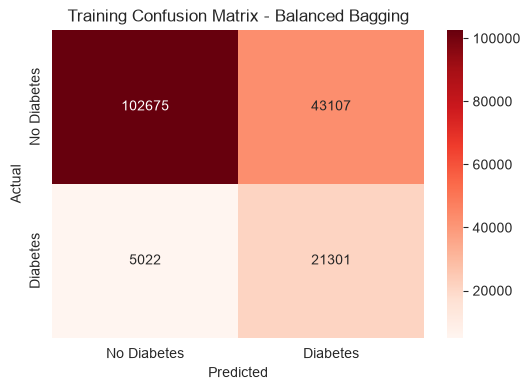

Training Confusion Matrix Breakdown
True Negatives:  102675
False Positives: 43107
False Negatives: 5022
True Positives:  21301


In [55]:
train_cm = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Unpack confusion matrix values
cm_values = train_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Training Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [56]:
y_test_pred = model.predict(X_test)

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("Test Accuracy", round(test_acc, 4))
print("Test Precision", round(test_precision, 4))
print("Test Recall", round(test_recall, 4))
print("Test F1 Score", round(test_f1, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.7083
Test Precision: 0.3153
Test Recall: 0.7746
Test F1 Score: 0.4482

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9448    0.6963    0.8017     48595
           1     0.3153    0.7746    0.4482      8774

    accuracy                         0.7083     57369
   macro avg     0.6300    0.7354    0.6249     57369
weighted avg     0.8485    0.7083    0.7477     57369



In [57]:
y_test_proba_all = model.predict_proba(X_test)
y_test_proba = y_test_proba_all[:, 1]
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print("Test ROC-AUC", round(test_roc_auc, 4))

Test ROC-AUC: 0.8107


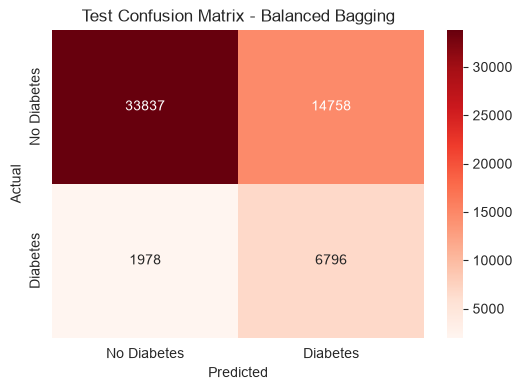

Test Confusion Matrix Breakdown
True Negatives:  33837
False Positives: 14758
False Negatives: 1978
True Positives:  6796


In [58]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation


Balanced Bagging performed well on Feature Set B, with a test accuracy of 0.71 and a ROC AUC of 0.81. Its main strength was recall, which reached 0.7746 on the test set, meaning the model detected most diabetes cases. 

This is particularly important in this project because false negatives are more serious than false positives missing a person at risk of diabetes is a more costly outcome than incorrectly flagging someone for further assessment. The model produced 1,978 false negatives, which is lower than several of the earlier baseline models, but it also generated 14,758 false positives, resulting in relatively low precision at 0.32. 

In [59]:
bbb_results_b = {
    'Feature Set': 'B',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(bbb_results_b)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,B,Logistic Regression,0.7175,0.7168,0.3206,0.7613,0.4512,0.8115,14155,2094
1,B,Linear SVM,0.7132,0.7125,0.3180,0.7683,0.4498,0.8114,14459,2033
2,B,RBF SVM,0.7305,0.7074,0.3136,0.7678,0.4453,0.7998,14749,2037
3,B,Gaussian Naive Bayes,0.7536,0.7530,0.3313,0.6041,0.4279,0.7767,10697,3474
4,B,Balanced Random Forest,0.8862,0.5570,0.2286,0.7990,0.3555,0.6947,23649,1764
5,B,Balanced Bagging,0.7204,0.7083,0.3153,0.7746,0.4482,0.8107,14758,1978


### 6.3 Easy Ensemble


The Easy Ensemble method is specifically designed for highly imbalanced datasets.

It creates multiple balanced subsets of the majority class, trains an AdaBoost classifier on each, and then aggregates their predictions.

This approach combines boosting's ability to focus on hard-to-classify cases with balanced sampling to improve minority recall.


In [60]:
easy_model = EasyEnsembleClassifier(
    n_estimators=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

easy_model.fit(X_train_sub, y_train_sub)

model = easy_model
model_name = "Easy Ensemble"

In [61]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("\nTraining Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.7183

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9447    0.7089    0.8100     16941
           1     0.3233    0.7702    0.4554      3059

    accuracy                         0.7183     20000
   macro avg     0.6340    0.7395    0.6327     20000
weighted avg     0.8497    0.7183    0.7557     20000



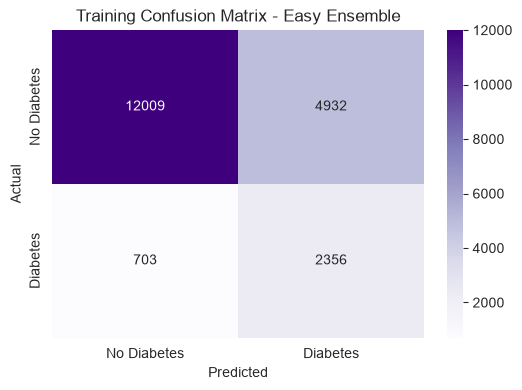

Training Confusion Matrix Breakdown
True Negatives:  12009
False Positives: 4932
False Negatives: 703
True Positives:  2356


In [62]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn_train, fp_train, fn_train, tp_train = train_cm.ravel()

print("Training Confusion Matrix Breakdown")
print("True Negatives", tn_train)
print("False Positives", fp_train)
print("False Negatives", fn_train)
print("True Positives", tp_train)

In [63]:
y_test_pred = model.predict(X_test)
y_test_prob_all = model.predict_proba(X_test)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, pos_label=1)
test_recall = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Test Precision", round(test_precision, 4))
print("Test Recall", round(test_recall, 4))
print("Test F1 Score", round(test_f1, 4))
print("Test ROC AUC", round(test_roc_auc, 4))

print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.2646
Test Precision: 0.1703
Test Recall: 0.9836
Test F1 Score: 0.2903
Test ROC AUC: 0.7414

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9785    0.1348    0.2369     48595
           1     0.1703    0.9836    0.2903      8774

    accuracy                         0.2646     57369
   macro avg     0.5744    0.5592    0.2636     57369
weighted avg     0.8549    0.2646    0.2451     57369



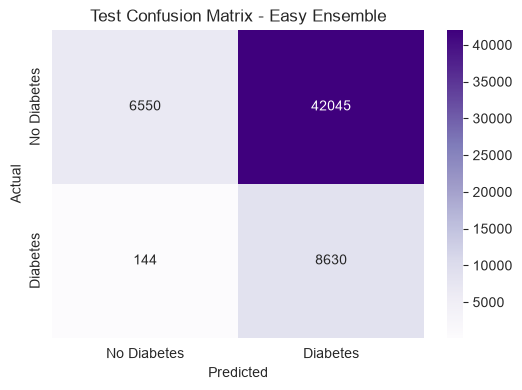

Test Confusion Matrix Breakdown
True Negatives:  6550
False Positives: 42045
False Negatives: 144
True Positives:  8630


In [64]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation


Easy Ensemble strongly prioritised recall, achieving 0.98 on the test set, which meant that very few diabetes cases were missed. This is important in the context of the project because false negatives are the more costly error. The model produced only 144 false negatives, which is the best result from a case-detection perspective. However, this performance came with a severe trade-off: precision was only 0.17, accuracy was 0.26, and the model generated 42,045 false positives. This indicates that the classifier labelled a very large proportion of cases as diabetes, including many that were actually non-diabetic. As a result, although Easy Ensemble is highly effective at minimising missed diabetes cases, it does so at the expense of overall reliability and would likely create too many false alarms for practical use.


In [65]:
easy_results_b = {
    'Feature Set': 'B',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(easy_results_b)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,B,Logistic Regression,0.7175,0.7168,0.3206,0.7613,0.4512,0.8115,14155,2094
1,B,Linear SVM,0.7132,0.7125,0.3180,0.7683,0.4498,0.8114,14459,2033
2,B,RBF SVM,0.7305,0.7074,0.3136,0.7678,0.4453,0.7998,14749,2037
3,B,Gaussian Naive Bayes,0.7536,0.7530,0.3313,0.6041,0.4279,0.7767,10697,3474
4,B,Balanced Random Forest,0.8862,0.5570,0.2286,0.7990,0.3555,0.6947,23649,1764
5,B,Balanced Bagging,0.7204,0.7083,0.3153,0.7746,0.4482,0.8107,14758,1978
6,B,Easy Ensemble,0.7183,0.2646,0.1703,0.9836,0.2903,0.7414,42045,144


### 6.4 Voting Classifier

A Voting Classifier combines predictions from multiple base models (for example logistic regression, SVM, and Naive Bayes) to form a consensus.

In soft voting, it averages predicted probabilities rather than hard class labels, allowing models with higher confidence to influence the final decision more strongly.


In [66]:
X_train_sub, X_train_sub_rest, y_train_sub, y_train_sub_rest = train_test_split(
    X_train_scaled,
    y_train,
    train_size=30000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

voting_estimators = [
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    )),
    ('nb', GaussianNB()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
]

voting_model = VotingClassifier(
    estimators=voting_estimators,
    voting='soft'
)

voting_model.fit(X_train_sub, y_train_sub)

model = voting_model
model_name = "Voting Classifier"

In [67]:
y_train_pred = model.predict(X_train_sub)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("\nTraining Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))

Training Accuracy: 0.8162

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9600    0.8170    0.8828     25412
           1     0.4446    0.8115    0.5745      4588

    accuracy                         0.8162     30000
   macro avg     0.7023    0.8142    0.7286     30000
weighted avg     0.8812    0.8162    0.8356     30000



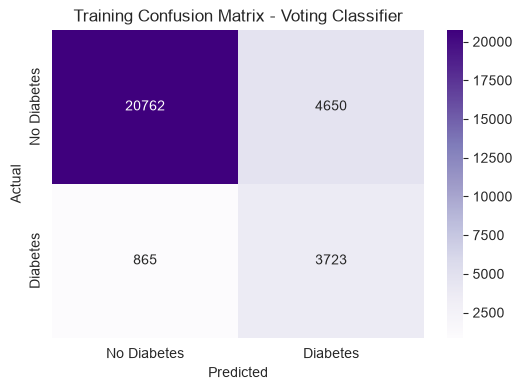

Training Confusion Matrix Breakdown
True Negatives:  20762
False Positives: 4650
False Negatives: 865
True Positives:  3723


In [68]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn_train, fp_train, fn_train, tp_train = train_cm.ravel()

print("Training Confusion Matrix Breakdown")
print("True Negatives", tn_train)
print("False Positives", fp_train)
print("False Negatives", fn_train)
print("True Positives", tp_train)

In [69]:
y_test_pred = model.predict(X_test_scaled)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.7635
Precision: 0.3481
Recall: 0.6257
F1-score: 0.4473
ROC AUC: 0.8017

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9211    0.7884    0.8496     48595
           1     0.3481    0.6257    0.4473      8774

    accuracy                         0.7635     57369
   macro avg     0.6346    0.7071    0.6485     57369
weighted avg     0.8334    0.7635    0.7881     57369



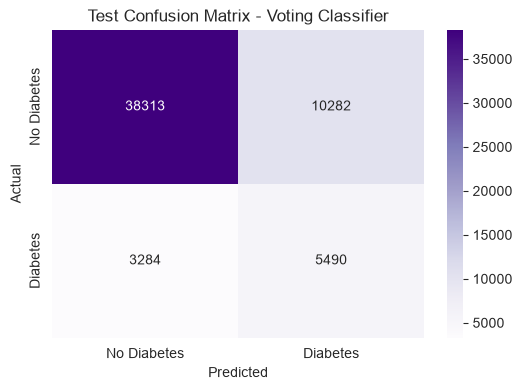

Test Confusion Matrix Breakdown
True Negatives:  38313
False Positives: 10282
False Negatives: 3284
True Positives:  5490


In [70]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

In [71]:
voting_results_b = {
    'Feature Set': 'B',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn
}

all_results.append(voting_results_b)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,B,Logistic Regression,0.7175,0.7168,0.3206,0.7613,0.4512,0.8115,14155,2094
1,B,Linear SVM,0.7132,0.7125,0.3180,0.7683,0.4498,0.8114,14459,2033
2,B,RBF SVM,0.7305,0.7074,0.3136,0.7678,0.4453,0.7998,14749,2037
3,B,Gaussian Naive Bayes,0.7536,0.7530,0.3313,0.6041,0.4279,0.7767,10697,3474
4,B,Balanced Random Forest,0.8862,0.5570,0.2286,0.7990,0.3555,0.6947,23649,1764
5,B,Balanced Bagging,0.7204,0.7083,0.3153,0.7746,0.4482,0.8107,14758,1978
6,B,Easy Ensemble,0.7183,0.2646,0.1703,0.9836,0.2903,0.7414,42045,144
7,B,Voting Classifier,0.8162,0.7635,0.3481,0.6257,0.4473,0.8017,10282,3284


### Observation

The Voting Classifier showed a relatively balanced performance on Feature Set B, achieving a test accuracy of 0.76 and a ROC AUC of 0.80. Compared with the other ensemble models, it did not achieve the highest recall, but it maintained a more practical trade-off between sensitivity and precision. Its recall of 0.63 means that some diabetes cases were still missed. However, the model also reduced false positives compared with other ensemble methods, and this led to a better precision of 0.35. Overall, the Voting Classifier appears to generalise more steadily and offers a more balanced compromise between case detection and prediction reliability.

### 6.5 Stacking Classifier


Stacking is a two-level ensemble method.

Base models (level 1) make predictions, and a meta-model (level 2) learns how to best combine those predictions.

The meta-model can capture relationships between model outputs, often improving accuracy and generalisation.


In [72]:
X_train_sub_scaled, X_train_sub_scaled_rest, y_train_sub, y_train_sub_rest = train_test_split(
    X_train_scaled,
    y_train,
    train_size=30000,
    random_state=RANDOM_STATE,
    stratify=y_train
)

stacking_estimators = [
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    )),
    ('nb', GaussianNB()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
]

stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    cv=3
)

stacking_model.fit(X_train_sub_scaled, y_train_sub)

model = stacking_model
model_name = "Stacking Classifier"

In [73]:
y_train_pred = model.predict(X_train_sub_scaled)
train_acc = accuracy_score(y_train_sub, y_train_pred)

print("Training Accuracy", round(train_acc, 4))
print("\nTraining Classification Report:")
print(classification_report(y_train_sub, y_train_pred, digits=4))


Training Accuracy: 0.7582

Training Classification Report:
              precision    recall  f1-score   support

           0     0.9654    0.7412    0.8385     25412
           1     0.3730    0.8527    0.5189      4588

    accuracy                         0.7582     30000
   macro avg     0.6692    0.7969    0.6787     30000
weighted avg     0.8748    0.7582    0.7897     30000



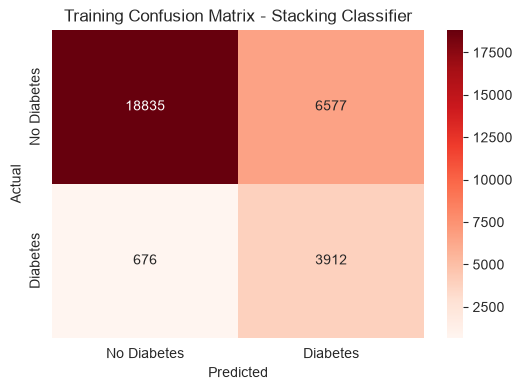

Training Confusion Matrix Breakdown
True Negatives:  18835
False Positives: 6577
False Negatives: 676
True Positives:  3912


In [74]:
train_cm = confusion_matrix(y_train_sub, y_train_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    train_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Training Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn_train, fp_train, fn_train, tp_train = train_cm.ravel()

print("Training Confusion Matrix Breakdown")
print("True Negatives", tn_train)
print("False Positives", fp_train)
print("False Negatives", fn_train)
print("True Positives", tp_train)


In [75]:
y_test_pred = model.predict(X_test_scaled)
# Probability of the positive class (class 1)
y_test_prob_all = model.predict_proba(X_test_scaled)
y_test_prob = y_test_prob_all[:, 1]
test_acc = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy", round(test_acc, 4))
print("Precision", round(test_precision, 4))
print("Recall", round(test_recall, 4))
print("F1-score", round(test_f1, 4))
print("ROC AUC", round(test_roc_auc, 4))

print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, digits=4))

Test Accuracy: 0.7226
Precision: 0.3237
Recall: 0.7477
F1-score: 0.4518
ROC AUC: 0.8119

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9403    0.7180    0.8143     48595
           1     0.3237    0.7477    0.4518      8774

    accuracy                         0.7226     57369
   macro avg     0.6320    0.7328    0.6331     57369
weighted avg     0.8460    0.7226    0.7588     57369



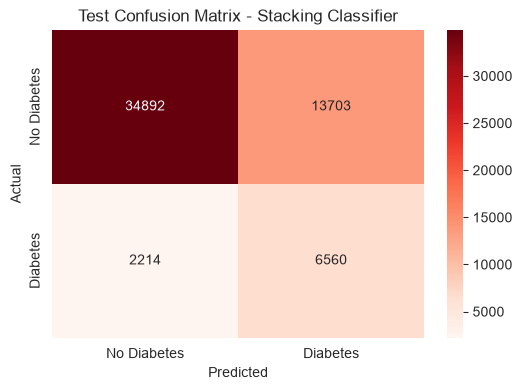

Test Confusion Matrix Breakdown
True Negatives:  34892
False Positives: 13703
False Negatives: 2214
True Positives:  6560


In [76]:
test_cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    test_cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title(f"Test Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

cm_values = test_cm.ravel()
tn = cm_values[0]
fp = cm_values[1]
fn = cm_values[2]
tp = cm_values[3]
print("Test Confusion Matrix Breakdown")
print("True Negatives", tn)
print("False Positives", fp)
print("False Negatives", fn)
print("True Positives", tp)

### Observation

The Stacking Classifier showed a reasonably strong recall-focused performance on Feature Set B, with a test accuracy of 0.72 and a ROC AUC of 0.81. Its recall of 0.75 means that it detected a large proportion of diabetes cases, which is important in this project because false negatives are more costly than false positives. Compared with the Voting Classifier, the stacking model appears to prioritise sensitivity more strongly, which improves case detection but keeps precision relatively low at 0.32. Overall, it offers a better balance than Easy Ensemble and Balanced Random Forest, but it is still less precise than would be ideal for a final deployment model.


In [1]:
stacking_results_b = {
    'Feature Set': 'B',
    'Model': model_name,
    'Training Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1-score': test_f1,
    'ROC AUC': test_roc_auc,
    'False Positives': fp,
    'False Negatives': fn,
}

all_results.append(stacking_results_b)
pd.DataFrame(all_results).round(4)

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,B,Logistic Regression,0.7175,0.7168,0.3206,0.7613,0.4512,0.8115,14155,2094
1,B,Linear SVM,0.7132,0.7125,0.3180,0.7683,0.4498,0.8114,14459,2033
2,B,RBF SVM,0.7305,0.7074,0.3136,0.7678,0.4453,0.7998,14749,2037
3,B,Gaussian Naive Bayes,0.7536,0.7530,0.3313,0.6041,0.4279,0.7767,10697,3474
4,B,Balanced Random Forest,0.8862,0.5570,0.2286,0.7990,0.3555,0.6947,23649,1764
5,B,Balanced Bagging,0.7204,0.7083,0.3153,0.7746,0.4482,0.8107,14758,1978
6,B,Easy Ensemble,0.7183,0.2646,0.1703,0.9836,0.2903,0.7414,42045,144
7,B,Voting Classifier,0.8162,0.7635,0.3481,0.6257,0.4473,0.8017,10282,3284
8,B,Stacking Classifier,0.7582,0.7226,0.3237,0.7477,0.4518,0.8119,13703,2214


In [78]:
results_b = pd.DataFrame(all_results).round(4)

results_b = results_b.sort_values(
    by=['Recall', 'False Negatives'],
    ascending=[False, True]
).reset_index(drop=True)

results_b

,Feature Set,Model,Training Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC AUC,False Positives,False Negatives
0,B,Easy Ensemble,0.7183,0.2646,0.1703,0.9836,0.2903,0.7414,42045,144
1,B,Balanced Random Forest,0.8862,0.5570,0.2286,0.7990,0.3555,0.6947,23649,1764
2,B,Balanced Bagging,0.7204,0.7083,0.3153,0.7746,0.4482,0.8107,14758,1978
3,B,Linear SVM,0.7132,0.7125,0.3180,0.7683,0.4498,0.8114,14459,2033
4,B,RBF SVM,0.7305,0.7074,0.3136,0.7678,0.4453,0.7998,14749,2037
5,B,Logistic Regression,0.7175,0.7168,0.3206,0.7613,0.4512,0.8115,14155,2094
6,B,Stacking Classifier,0.7582,0.7226,0.3237,0.7477,0.4518,0.8119,13703,2214
7,B,Voting Classifier,0.8162,0.7635,0.3481,0.6257,0.4473,0.8017,10282,3284
8,B,Gaussian Naive Bayes,0.7536,0.7530,0.3313,0.6041,0.4279,0.7767,10697,3474


In [79]:
results_b.to_csv('all_model_results_b.csv', index=False)
print('Saved: all_model_results_b.csv')

Saved: all_model_results_b.csv


## 7.0 Feature Set B - Summary and Conclusions

Feature Set B included the original variables together with engineered features such as `risk_factor_count`, `overall_health_burden`, and BMI category groupings. The purpose of this feature set was to test whether clinically informed feature engineering could improve diabetes prediction compared with the original variables alone. For this project, recall and false negatives were more important than accuracy, because missing someone at risk of diabetes is more serious than incorrectly flagging them for further screening.

### Model Comparison Table

| Feature Set | Model | Training Accuracy | Test Accuracy | Precision | Recall | F1-score | ROC AUC | False Positives | False Negatives |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| B | Easy Ensemble | 0.7183 | 0.2646 | 0.1703 | 0.9836 | 0.2903 | 0.7414 | 42045 | 144 |
| B | Balanced Random Forest | 0.8862 | 0.5570 | 0.2286 | 0.7990 | 0.3555 | 0.6947 | 23649 | 1764 |
| B | Balanced Bagging | 0.7204 | 0.7083 | 0.3153 | 0.7746 | 0.4482 | 0.8107 | 14758 | 1978 |
| B | Linear SVM | 0.7132 | 0.7125 | 0.3180 | 0.7683 | 0.4498 | 0.8114 | 14459 | 2033 |
| B | RBF SVM | 0.7305 | 0.7074 | 0.3136 | 0.7678 | 0.4453 | 0.7998 | 14749 | 2037 |
| B | Logistic Regression | 0.7175 | 0.7168 | 0.3206 | 0.7613 | 0.4512 | 0.8115 | 14155 | 2094 |
| B | Stacking Classifier | 0.7582 | 0.7226 | 0.3237 | 0.7477 | 0.4518 | 0.8119 | 13703 | 2214 |
| B | Voting Classifier | 0.8162 | 0.7635 | 0.3481 | 0.6257 | 0.4473 | 0.8017 | 10282 | 3284 |
| B | Gaussian Naive Bayes | 0.7536 | 0.7530 | 0.3313 | 0.6041 | 0.4279 | 0.7767 | 10697 | 3474 |

### Summary

The results showed that Balanced Bagging performed best on the metrics that matter most for this project on Feature Set B. It achieved the highest recall among practical models on the full test set at 0.7746 and produced the fewest false negatives (1,978). This means it missed the fewest diabetes cases among usable screening options.

Linear SVM and logistic regression were also strong and highly competitive. Linear SVM achieved a recall of 0.7683 with 2,033 false negatives, while logistic regression achieved a recall of 0.7613 with 2,094 false negatives. These results were very close to Balanced Bagging, which suggests that the simpler models remained effective even after adding engineered features.

Among the ensemble approaches, Stacking Classifier was the strongest overall ensemble model. It achieved a test accuracy of 0.7226, a recall of 0.7477, the highest ensemble F1-score (0.4518), and the highest ROC AUC (0.8119). Although it did not outperform Balanced Bagging or the best individual models on false negatives, it provided the best overall balance among the ensemble methods.

Voting Classifier achieved the highest test accuracy at 0.7635, but this was not matched by recall. Its recall dropped to 0.6257, and it missed 3,284 diabetes cases. This is an important result because it shows that a model can appear strong on accuracy while still performing less well on the screening objective of identifying positive cases.

Gaussian Naive Bayes remained useful as a fast benchmark model, but its recall was lower at 0.6041, and it produced 3,474 false negatives. This again reinforced the point that accuracy alone is not enough when evaluating models for a medical screening problem.

Easy Ensemble and Balanced Random Forest prioritised recall too aggressively. Easy Ensemble produced the fewest false negatives overall (144) and the highest recall (0.9836), but this came at the cost of 42,045 false positives and a very low test accuracy of 0.2646. Balanced Random Forest showed a similar pattern, with high recall (0.7990) and relatively few false negatives (1,764), but too many false positives (23,649). These models were highly sensitive, but they over-predicted diabetes so often that they would be difficult to use in practice.

Overall, the engineered features in Feature Set B added some useful clinical structure, especially through the BMI categories and combined burden indicators. However, the improvement over Feature Set A was limited. The best-performing practical models on Feature Set B were only slightly better than, or similar to, the strongest models from Feature Set A, which suggests that the original variables already contained most of the predictive noise in the data set.

### What I took away from Feature Set B

1. Balanced Bagging was the strongest practical model for the project objective on Feature Set B. It achieved the highest practical recall on the full test set and the fewest false negatives (1,978).
2. Linear SVM and logistic regression remained very strong alternatives. Their results were close to Balanced Bagging, showing that simpler models can still perform very well even after feature engineering.
3. Stacking Classifier was the best ensemble overall. It delivered the most balanced ensemble performance, with strong recall, the best ensemble F1-score, and the highest ROC AUC.
4. Voting Classifier improved accuracy, but not in the way that mattered most for this project. It missed too many positive cases compared with the stronger recall-focused models.
5. Gaussian Naive Bayes was useful as a fast benchmark, but weaker on recall. Its higher accuracy did not make it a better screening model because it still missed many people at risk.
6. Easy Ensemble and Balanced Random Forest showed the danger of optimising recall too aggressively. They reduced false negatives sharply, but produced so many false positives that they would create too many false alarms in practice.
7. Accuracy alone is not an appropriate metric for this problem. Recall, false negatives, and the trade-off between sensitivity and practical reliability were much more informative for evaluating diabetes screening models.

### Conclusion

For diabetes screening using Feature Set B, Balanced Bagging would be the preferred model if the main priority is to minimise false negatives. It achieved the highest recall among the comparable practical models and missed the fewest diabetes cases (1,978).

If the goal is to choose the best ensemble model overall, then Stacking Classifier would be the strongest ensemble choice. It did not achieve the best recall, but it provided the best overall balance across recall, F1-score, ROC AUC, and general model behaviour.

Compared with Feature Set A, Feature Set B did not produce a major improvement in predictive performance. The engineered features added interpretability, but they did not clearly outperform the original variables on the most important screening metrics in feature set A. This suggests that the original predictors already captured most of the useful signal for identifying diabetes risk, while the engineered features mainly added depth and interpretability rather than a large performance gain.
